# 📊 Toàn diện Phân tích Khám phá Dữ liệu (EDA) — CelebA-Spoof Dataset
**Dự án PBL6 — SmartFace Anti-Spoofing System**

Notebook này thực hiện **phân tích khám phá chuyên sâu (Comprehensive Exploratory Data Analysis - EDA)** bộ dữ liệu **CelebA-Spoof** trên môi trường Kaggle:
1. **Tổng quan Metadata & Cấu trúc:** So sánh quy mô tập Train vs tập Test.
2. **Kiểm định Subject-Disjoint:** Chứng minh tính độc lập về đối tượng (`Train subjects ∩ Test subjects == ∅`).
3. **Phân phối Nhãn 3 Class & 10 Loại Tấn công:** Real vs Physical Spoof vs Digital Spoof và chi tiết từng loại attack.
4. **Phân tích Điều kiện Môi trường & Ánh sáng:** Illumination (Backlight, Dim, Dark, Strong...) & Environment (Indoor, Outdoor).
5. **Kiểm tra Chất lượng Bounding Box:** Tỷ lệ file `_BB.txt` rỗng/lỗi, phân phối kích thước mặt, aspect ratio, lý do áp dụng crop 1.5×.
6. **Gallery Trực quan:** Hiển thị mẫu ảnh tiêu biểu của từng loại spoof và bbox crop thực tế.

In [1]:
# Cell 1: Thư viện cần thiết
import os, sys, json, time
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from tabulate import tabulate
from collections import Counter

# Cấu hình thẩm mỹ biểu đồ
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.sans-serif"] = "DejaVu Sans"

print("✅ Thư viện đã sẵn sàng!")

✅ Thư viện đã sẵn sàng!


## ⚙️ 2. Tự động Dò tìm Đường dẫn Dataset trên Kaggle

In [2]:
# Cell 2: Khởi tạo đường dẫn dữ liệu (SIÊU TỐC <0.01s - KHÔNG DÙNG GLOB ĐỆ QUY)
import os, sys

def find_data_root():
    # 1. Các đường dẫn trực tiếp phổ biến nhất trên Kaggle
    known_candidates = [
        "/kaggle/input/datasets/attentionlayer241/celeba-spoof-for-face-antispoofing/CelebA_Spoof_/CelebA_Spoof",
        "/kaggle/input/celeba-spoof-for-face-antispoofing/CelebA_Spoof_/CelebA_Spoof",
        "/kaggle/input/celeba-spoof/CelebA_Spoof_/CelebA_Spoof",
        "./CelebA_Spoof",
    ]
    for p in known_candidates:
        if os.path.exists(os.path.join(p, "metas/intra_test/train_label.json")):
            return p
            
    # 2. Quét nông (shallow check) cấp 1-2 trong /kaggle/input (tốn 0.001s)
    if os.path.exists("/kaggle/input"):
        for item in os.listdir("/kaggle/input"):
            base_dir = os.path.join("/kaggle/input", item)
            if not os.path.isdir(base_dir):
                continue
            if "model" in item.lower() or "checkpoint" in item.lower():
                continue
            for sub_p in ["", "CelebA_Spoof_/CelebA_Spoof", "CelebA_Spoof", "celeba-spoof"]:
                trial = os.path.join(base_dir, sub_p) if sub_p else base_dir
                if os.path.exists(os.path.join(trial, "metas/intra_test/train_label.json")):
                    return trial

    return known_candidates[0]

DATA_ROOT = find_data_root()

if os.path.exists(os.path.join(DATA_ROOT, "metas/intra_test/train_label.json")):
    print(f"✅ Đã tìm thấy DATA_ROOT: {DATA_ROOT}")
else:
    print(f"⚠️ Chưa tìm thấy data cục bộ, thiết lập mặc định Kaggle: {DATA_ROOT}")
    print("   -> Hãy 'Add Data' đúng dataset CelebA-Spoof rồi kiểm tra lại qua /kaggle/input")

TRAIN_JSON = os.path.join(DATA_ROOT, "metas/intra_test/train_label.json")
TEST_JSON  = os.path.join(DATA_ROOT, "metas/intra_test/test_label.json")

print(f"Train Metadata: {TRAIN_JSON} (Exists: {os.path.exists(TRAIN_JSON)})")
print(f"Test Metadata : {TEST_JSON} (Exists: {os.path.exists(TEST_JSON)})")


✅ Đã tìm thấy DATA_ROOT: /kaggle/input/datasets/attentionlayer241/celeba-spoof-for-face-antispoofing/CelebA_Spoof_/CelebA_Spoof
Train Metadata: /kaggle/input/datasets/attentionlayer241/celeba-spoof-for-face-antispoofing/CelebA_Spoof_/CelebA_Spoof/metas/intra_test/train_label.json (Exists: True)
Test Metadata : /kaggle/input/datasets/attentionlayer241/celeba-spoof-for-face-antispoofing/CelebA_Spoof_/CelebA_Spoof/metas/intra_test/test_label.json (Exists: True)


## 📂 3. Nạp Metadata và Khảo sát Cấu trúc Entry

In [3]:
# Cell 3: Nạp toàn bộ metadata của Train và Test
print("Đang nạp Train Metadata...")
t0 = time.time()
with open(TRAIN_JSON, "r") as f:
    train_meta = json.load(f)
print(f"--> Đã nạp {len(train_meta):,} entries tập Train ({time.time() - t0:.2f}s)")

print("Đang nạp Test Metadata...")
t0 = time.time()
with open(TEST_JSON, "r") as f:
    test_meta = json.load(f)
print(f"--> Đã nạp {len(test_meta):,} entries tập Test ({time.time() - t0:.2f}s)")

# Khảo sát entry mẫu
sample_key = list(train_meta.keys())[0]
sample_val = train_meta[sample_key]

print(f"\nEntry mẫu (Path): {sample_key}")
print(f"Độ dài list nhãn thuộc tính: {len(sample_val)} phần tử")
print(f"40 thuộc tính khuôn mặt (0..39): {sample_val[:10]} ...")
print(f"Thuộc tính Spoof Type (index 40) : {sample_val[40]}")
if len(sample_val) > 41:
    print(f"Thuộc tính Illumination (index 41): {sample_val[41]}")
if len(sample_val) > 42:
    print(f"Thuộc tính Environment (index 42) : {sample_val[42]}")

Đang nạp Train Metadata...
--> Đã nạp 494,405 entries tập Train (4.51s)
Đang nạp Test Metadata...
--> Đã nạp 67,170 entries tập Test (0.69s)

Entry mẫu (Path): Data/train/2623/live/000000.jpg
Độ dài list nhãn thuộc tính: 44 phần tử
40 thuộc tính khuôn mặt (0..39): [0, 1, 1, 0, 0, 0, 0, 0, 0, 0] ...
Thuộc tính Spoof Type (index 40) : 0
Thuộc tính Illumination (index 41): 0
Thuộc tính Environment (index 42) : 0


## 👥 4. Phân tích Đối tượng (Subject ID) & Kiểm định Subject-Disjoint
Theo tiêu chuẩn bảo mật sinh trắc học và giao thức kiểm thử intra-test của CelebA-Spoof:
- Các đối tượng xuất hiện trong tập Train **tuyệt đối không được phép xuất hiện** trong tập Test (`Train subjects ∩ Test subjects == ∅`).
- Kiểm tra tính subject-disjoint bằng cách trích xuất ID từ chuỗi đường dẫn ảnh (định dạng `Data/train/<subject_id>/...` hoặc `Data/test/<subject_id>/...`).

Tổng số subjects tập Train : 8,192
Tổng số subjects tập Test  : 1,004
Tổng số subjects toàn bộ   : 9,193
Số subjects bị trùng lặp   : 3
⚠️ CẢNH BÁO: Phát hiện 3 subjects bị trùng giữa Train và Test!
╒════════════════╤═══════════════╤═══════════════╤══════════╤═════════╤═══════════════╕
│ Tập            │   Số Subjects │   Min ảnh/sub │   Median │    Mean │   Max ảnh/sub │
╞════════════════╪═══════════════╪═══════════════╪══════════╪═════════╪═══════════════╡
│ Train Subjects │          8192 │             1 │       60 │ 60.3522 │           325 │
├────────────────┼───────────────┼───────────────┼──────────┼─────────┼───────────────┤
│ Test Subjects  │          1004 │             1 │       48 │ 66.9024 │           620 │
╘════════════════╧═══════════════╧═══════════════╧══════════╧═════════╧═══════════════╛


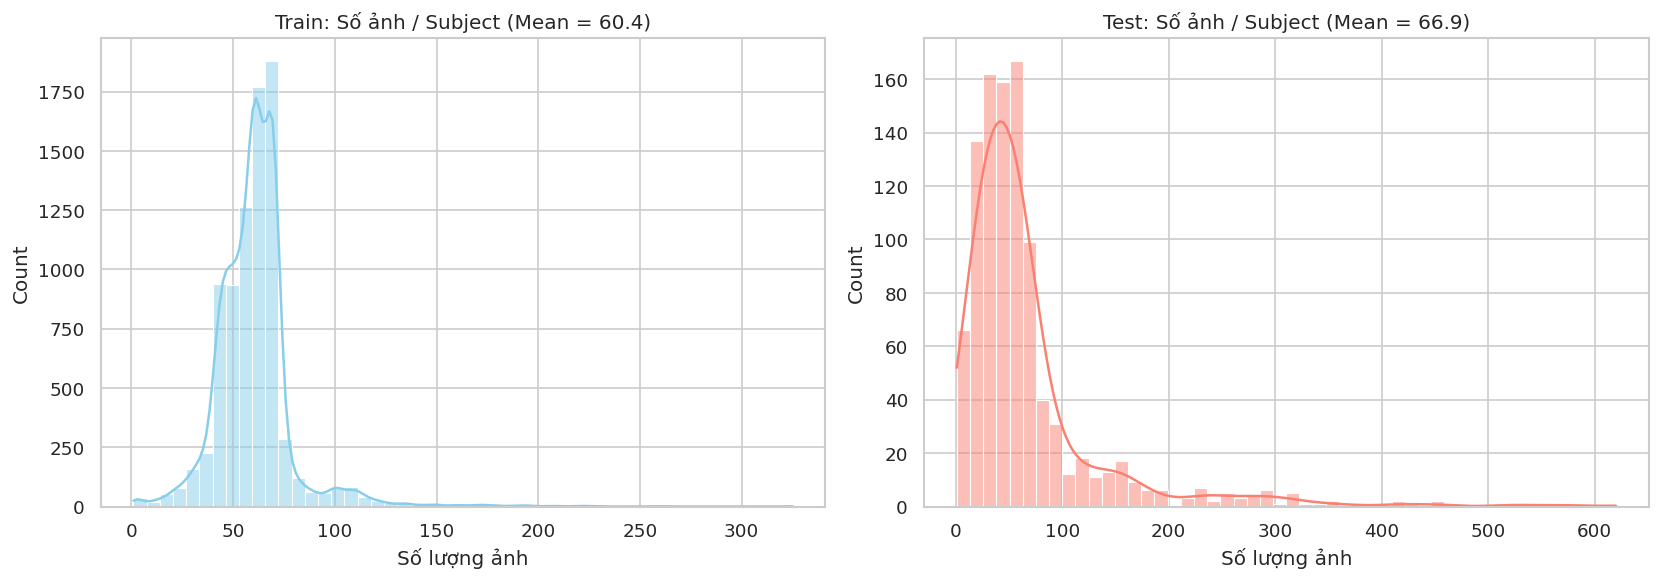

In [4]:
# Cell 4: Trích xuất Subject ID và kiểm định Disjoint
def extract_subject_id(rel_path):
    # Đường dẫn thông thường có dạng: 'Data/train/4242/live/xxxx.jpg' hoặc 'train/4242/...'
    parts = rel_path.replace("\\", "/").split("/")
    for i, p in enumerate(parts):
        if p in ["train", "test"] and i + 1 < len(parts):
            return parts[i + 1]
    # Fallback nếu cấu trúc khác
    return parts[1] if len(parts) > 2 else parts[0]

train_subjects_counter = Counter()
for k in train_meta.keys():
    s_id = extract_subject_id(k)
    train_subjects_counter[s_id] += 1

test_subjects_counter = Counter()
for k in test_meta.keys():
    s_id = extract_subject_id(k)
    test_subjects_counter[s_id] += 1

train_subjects = set(train_subjects_counter.keys())
test_subjects = set(test_subjects_counter.keys())
overlap_subjects = train_subjects & test_subjects

print("=" * 60)
print(f"Tổng số subjects tập Train : {len(train_subjects):,}")
print(f"Tổng số subjects tập Test  : {len(test_subjects):,}")
print(f"Tổng số subjects toàn bộ   : {len(train_subjects | test_subjects):,}")
print(f"Số subjects bị trùng lặp   : {len(overlap_subjects)}")
print("=" * 60)

if len(overlap_subjects) == 0:
    print("✅ XÁC NHẬN: Giao thức Intra-test hoàn toàn tuân thủ SUBJECT-DISJOINT (Zero Leakage)!")
else:
    print(f"⚠️ CẢNH BÁO: Phát hiện {len(overlap_subjects)} subjects bị trùng giữa Train và Test!")

# Thống kê số ảnh trên mỗi subject
train_imgs_per_sub = list(train_subjects_counter.values())
test_imgs_per_sub = list(test_subjects_counter.values())

sub_stats = [
    ["Train Subjects", len(train_subjects), np.min(train_imgs_per_sub), np.median(train_imgs_per_sub), np.mean(train_imgs_per_sub), np.max(train_imgs_per_sub)],
    ["Test Subjects",  len(test_subjects),  np.min(test_imgs_per_sub),  np.median(test_imgs_per_sub),  np.mean(test_imgs_per_sub),  np.max(test_imgs_per_sub)]
]
print(tabulate(sub_stats, headers=["Tập", "Số Subjects", "Min ảnh/sub", "Median", "Mean", "Max ảnh/sub"], tablefmt="fancy_grid"))

# Vẽ phân phối số ảnh/subject
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(train_imgs_per_sub, bins=50, ax=ax[0], color="skyblue", kde=True)
ax[0].set_title(f"Train: Số ảnh / Subject (Mean = {np.mean(train_imgs_per_sub):.1f})")
ax[0].set_xlabel("Số lượng ảnh")

sns.histplot(test_imgs_per_sub, bins=50, ax=ax[1], color="salmon", kde=True)
ax[1].set_title(f"Test: Số ảnh / Subject (Mean = {np.mean(test_imgs_per_sub):.1f})")
ax[1].set_xlabel("Số lượng ảnh")
plt.tight_layout()
plt.show()

## 🏷️ 5. Phân tích Phân phối 3 Lớp (Real vs Physical vs Digital)
Quy tắc phân loại đang áp dụng trong project:
- **Class 0 (Real / Live):** `v[40] == 0`
- **Class 1 (Physical Spoof):** `v[40] in [1, 2, 3, 4, 5, 6, 7]` (In giấy A4, poster, mặt nạ...)
- **Class 2 (Digital Spoof):** `v[40] >= 8` (Màn hình điện thoại, máy tính, tablet...)

╒═══════════════════╤════════════════════╤══════════════════╕
│ Class             │ Tập Train (494K)   │ Tập Test (67K)   │
╞═══════════════════╪════════════════════╪══════════════════╡
│ 0: Real Face      │ 162,462 (32.86%)   │ 19,923 (29.66%)  │
├───────────────────┼────────────────────┼──────────────────┤
│ 1: Physical Spoof │ 226,715 (45.86%)   │ 35,495 (52.84%)  │
├───────────────────┼────────────────────┼──────────────────┤
│ 2: Digital Spoof  │ 105,228 (21.28%)   │ 11,752 (17.50%)  │
╘═══════════════════╧════════════════════╧══════════════════╛


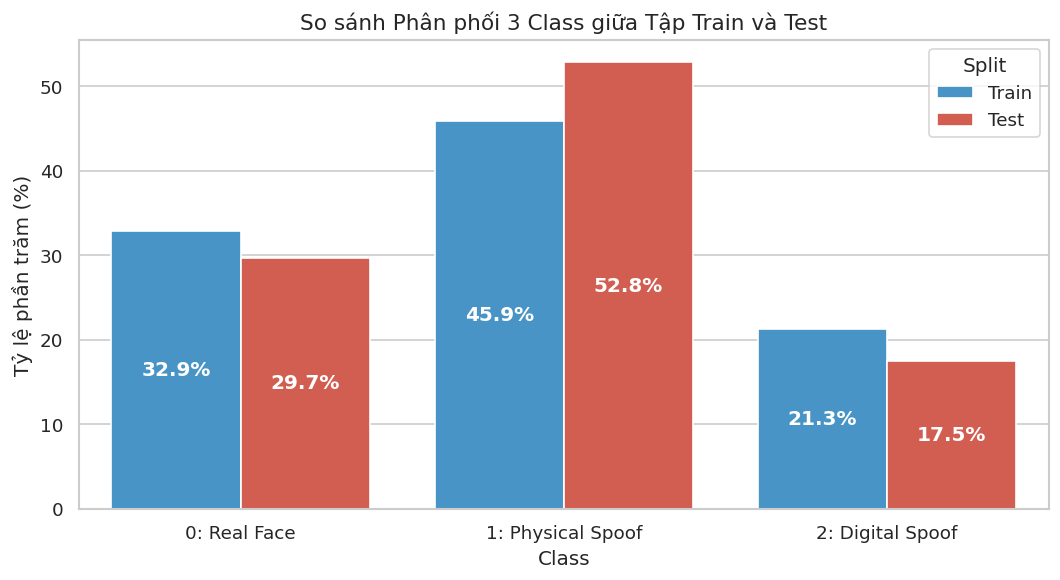

In [5]:
# Cell 5: Thống kê và vẽ biểu đồ 3 Class
def label_3c(v):
    lr = int(v[40])
    if lr == 0:
        return 0
    elif lr in [1, 2, 3, 4, 5, 6, 7]:
        return 1
    else:
        return 2

train_3c_counts = Counter([label_3c(v) for v in train_meta.values()])
test_3c_counts  = Counter([label_3c(v) for v in test_meta.values()])

class_labels = ["0: Real Face", "1: Physical Spoof", "2: Digital Spoof"]
n_tr = len(train_meta)
n_te = len(test_meta)

table_3c = []
for c in [0, 1, 2]:
    tr_cnt = train_3c_counts[c]
    te_cnt = test_3c_counts[c]
    table_3c.append([
        class_labels[c],
        f"{tr_cnt:,} ({tr_cnt/n_tr*100:.2f}%)",
        f"{te_cnt:,} ({te_cnt/n_te*100:.2f}%)"
    ])

print(tabulate(table_3c, headers=["Class", "Tập Train (494K)", "Tập Test (67K)"], tablefmt="fancy_grid"))

# Vẽ Grouped Bar Chart
df_plot = pd.DataFrame({
    "Class": class_labels * 2,
    "Tỷ lệ (%)": [train_3c_counts[c]/n_tr*100 for c in [0, 1, 2]] + [test_3c_counts[c]/n_te*100 for c in [0, 1, 2]],
    "Split": ["Train"] * 3 + ["Test"] * 3
})

plt.figure(figsize=(9, 5))
sns.barplot(data=df_plot, x="Class", y="Tỷ lệ (%)", hue="Split", palette=["#3498db", "#e74c3c"])
plt.title("So sánh Phân phối 3 Class giữa Tập Train và Test", fontsize=13)
plt.ylabel("Tỷ lệ phần trăm (%)")
for p in plt.gca().patches:
    h = p.get_height()
    if h > 0:
        plt.gca().annotate(f"{h:.1f}%", (p.get_x() + p.get_width() / 2., h / 2),
                           ha="center", va="center", color="white", fontweight="bold")
plt.tight_layout()
plt.show()

## 🎯 6. Phân tích Chi tiết 10 Loại Tấn công (Attack / Spoof Types)
Thuộc tính thứ 41 (index 40) trong CelebA-Spoof đại diện cho loại hình tấn công chi tiết:
- `0`: Live (Thật)
- `1`: Poster (Ảnh in khổ lớn)
- `2`: A4 (Ảnh in giấy A4)
- `3`: Face Mask (Mặt nạ khuôn mặt)
- `4`: Upper Body Mask (Mặt nạ nửa thân)
- `5`: Region Mask (Mặt nạ che một vùng)
- `6`: PC Screen (Replay màn hình máy tính)
- `7`: Pad / Tablet (Replay màn hình máy tính bảng)
- `8`: Phone (Replay màn hình điện thoại)
- `9`: 3D Mask (Mặt nạ silicon 3D cao cấp)

╒══════════════════════╤═══════════════╤═══════════╤══════════════╤══════════╕
│ Attack Type          │ Train Count   │ Train %   │ Test Count   │ Test %   │
╞══════════════════════╪═══════════════╪═══════════╪══════════════╪══════════╡
│ 0: Live (Real)       │ 162,462       │ 32.86%    │ 19,923       │ 29.66%   │
├──────────────────────┼───────────────┼───────────┼──────────────┼──────────┤
│ 1: Poster            │ 35,547        │ 7.19%     │ 3,600        │ 5.36%    │
├──────────────────────┼───────────────┼───────────┼──────────────┼──────────┤
│ 2: A4 Paper          │ 31,221        │ 6.31%     │ 5,421        │ 8.07%    │
├──────────────────────┼───────────────┼───────────┼──────────────┼──────────┤
│ 3: Face Mask         │ 31,776        │ 6.43%     │ 6,083        │ 9.06%    │
├──────────────────────┼───────────────┼───────────┼──────────────┼──────────┤
│ 4: Upper Body Mask   │ 33,647        │ 6.81%     │ 4,287        │ 6.38%    │
├──────────────────────┼───────────────┼───────────┼

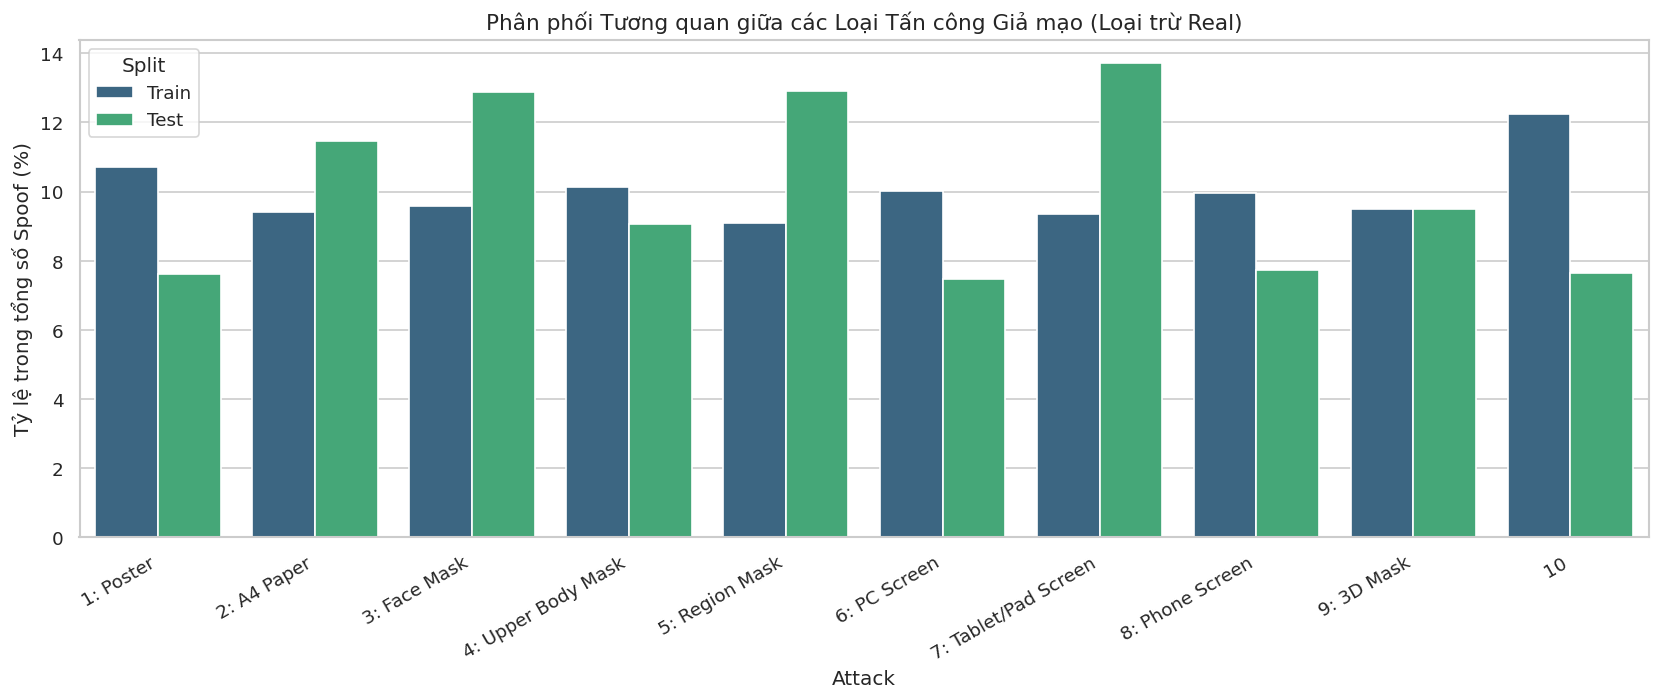

In [6]:
# Cell 6: Thống kê Attack Types chi tiết
ATTACK_TYPE_NAMES = {
    0: "0: Live (Real)",
    1: "1: Poster",
    2: "2: A4 Paper",
    3: "3: Face Mask",
    4: "4: Upper Body Mask",
    5: "5: Region Mask",
    6: "6: PC Screen",
    7: "7: Tablet/Pad Screen",
    8: "8: Phone Screen",
    9: "9: 3D Mask"
}

train_attack_counts = Counter([int(v[40]) for v in train_meta.values()])
test_attack_counts  = Counter([int(v[40]) for v in test_meta.values()])

all_attack_ids = sorted(list(set(train_attack_counts.keys()) | set(test_attack_counts.keys())))

table_attacks = []
for aid in all_attack_ids:
    name = ATTACK_TYPE_NAMES.get(aid, f"Unknown ({aid})")
    tr_c = train_attack_counts[aid]
    te_c = test_attack_counts[aid]
    table_attacks.append([
        name,
        f"{tr_c:,}", f"{tr_c/n_tr*100:.2f}%",
        f"{te_c:,}", f"{te_c/n_te*100:.2f}%"
    ])

print(tabulate(table_attacks, headers=["Attack Type", "Train Count", "Train %", "Test Count", "Test %"], tablefmt="fancy_grid"))

# Biểu đồ chi tiết các loại tấn công giả mạo (loại bỏ Real để nhìn rõ các class spoof hiếm)
spoof_ids = [aid for aid in all_attack_ids if aid != 0]
spoof_names = [ATTACK_TYPE_NAMES.get(aid, str(aid)) for aid in spoof_ids]
tr_spoof_pcts = [train_attack_counts[aid] / sum(train_attack_counts[x] for x in spoof_ids) * 100 for aid in spoof_ids]
te_spoof_pcts = [test_attack_counts[aid]  / sum(test_attack_counts[x] for x in spoof_ids) * 100 for aid in spoof_ids]

df_spoof_attacks = pd.DataFrame({
    "Attack": spoof_names * 2,
    "Tỷ lệ trong tổng số Spoof (%)": tr_spoof_pcts + te_spoof_pcts,
    "Split": ["Train"] * len(spoof_ids) + ["Test"] * len(spoof_ids)
})

plt.figure(figsize=(14, 6))
sns.barplot(data=df_spoof_attacks, x="Attack", y="Tỷ lệ trong tổng số Spoof (%)", hue="Split", palette="viridis")
plt.title("Phân phối Tương quan giữa các Loại Tấn công Giả mạo (Loại trừ Real)", fontsize=13)
plt.xticks(rotation=30, ha="right")
plt.ylabel("Tỷ lệ trong tổng số Spoof (%)")
plt.tight_layout()
plt.show()

## ☀️ 7. Phân tích Điều kiện Ánh sáng (Illumination) & Môi trường (Environment)
Khảo sát các thuộc tính môi trường tại index 41 (Illumination) và index 42 (Environment) nếu có trong annotation.

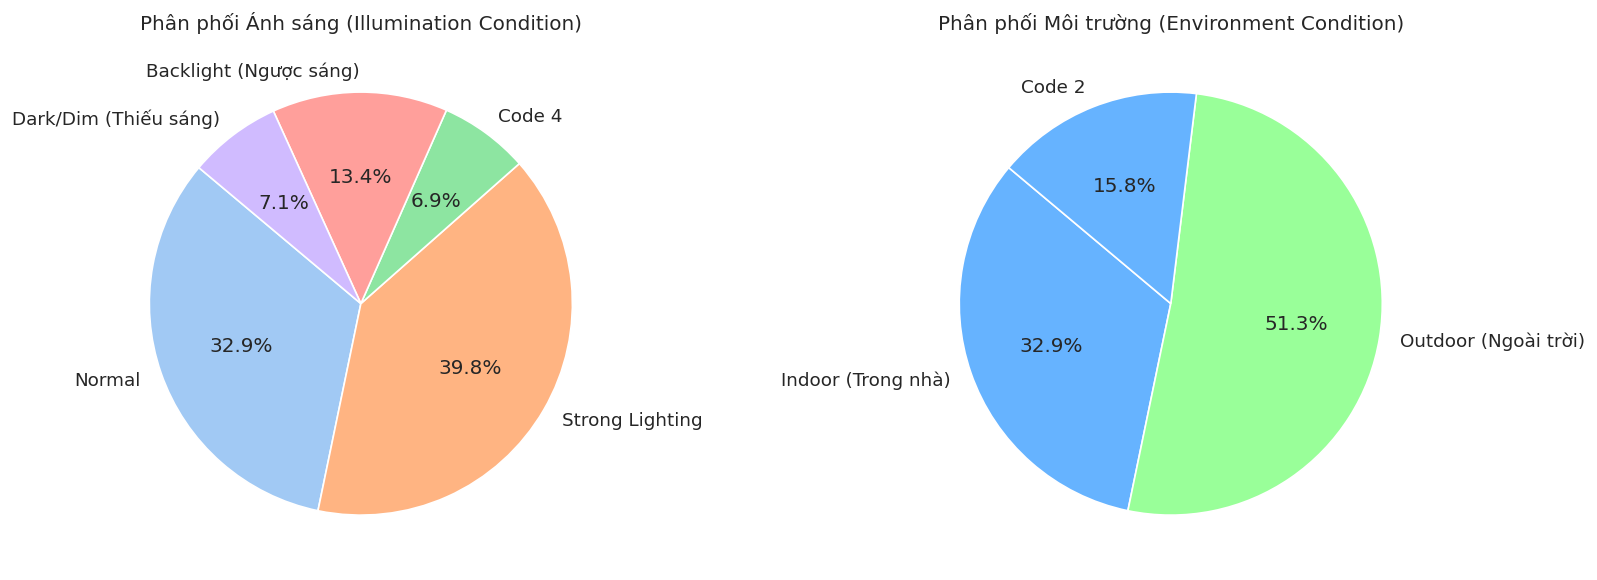

In [7]:
# Cell 7: Thống kê Illumination và Environment
# Kiểm tra sự tồn tại của index 41 và 42
sample_val = list(train_meta.values())[0]

if len(sample_val) > 42:
    ILLUMINATION_MAP = {
        0: "Normal",
        1: "Strong Lighting",
        2: "Backlight (Ngược sáng)",
        3: "Dark/Dim (Thiếu sáng)"
    }
    
    ENV_MAP = {
        0: "Indoor (Trong nhà)",
        1: "Outdoor (Ngoài trời)"
    }
    
    train_illum = Counter([int(v[41]) for v in train_meta.values() if len(v) > 41])
    train_env   = Counter([int(v[42]) for v in train_meta.values() if len(v) > 42])
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Illumination Pie Chart
    illum_labels = [ILLUMINATION_MAP.get(k, f"Code {k}") for k in train_illum.keys()]
    axes[0].pie(train_illum.values(), labels=illum_labels, autopct="%1.1f%%", startangle=140, colors=sns.color_palette("pastel"))
    axes[0].set_title("Phân phối Ánh sáng (Illumination Condition)")
    
    # Environment Pie Chart
    env_labels = [ENV_MAP.get(k, f"Code {k}") for k in train_env.keys()]
    axes[1].pie(train_env.values(), labels=env_labels, autopct="%1.1f%%", startangle=140, colors=["#66b3ff", "#99ff99"])
    axes[1].set_title("Phân phối Môi trường (Environment Condition)")
    
    plt.tight_layout()
    plt.show()
else:
    print("ℹ️ Dataset metadata hiện tại có 41 trường thuộc tính (đến index 40 - Spoof Type).")

## 📐 8. Khảo sát Chất lượng Bounding Box & Phân tích Kích thước Khuôn mặt
- Kiểm tra mẫu ngẫu nhiên `SAMPLE_CHECK_SIZE = 3000` file `_BB.txt`: tỷ lệ tồn tại, tỷ lệ file bị rỗng/thiếu toạ độ (có thể tăng số này nếu muốn khảo sát kỹ hơn, đổi trực tiếp trong Cell 8).
- Phân phối độ rộng ($W$), độ cao ($H$) và diện tích bbox so với ảnh gốc.
- Đánh giá sự cần thiết của Expanded Crop 1.5× và `cv2.BORDER_REFLECT_101`.

Khảo sát Bounding Boxes: 100%|██████████| 3000/3000 [00:54<00:00, 55.55it/s]



📊 Kết quả khảo sát trên 3,000 mẫu:
   - File _BB.txt tồn tại  : 3,000 (100.0%)
   - File _BB.txt hợp lệ   : 3,000 (100.0%)
   - File _BB.txt rỗng/lỗi : 0 (0.0%)


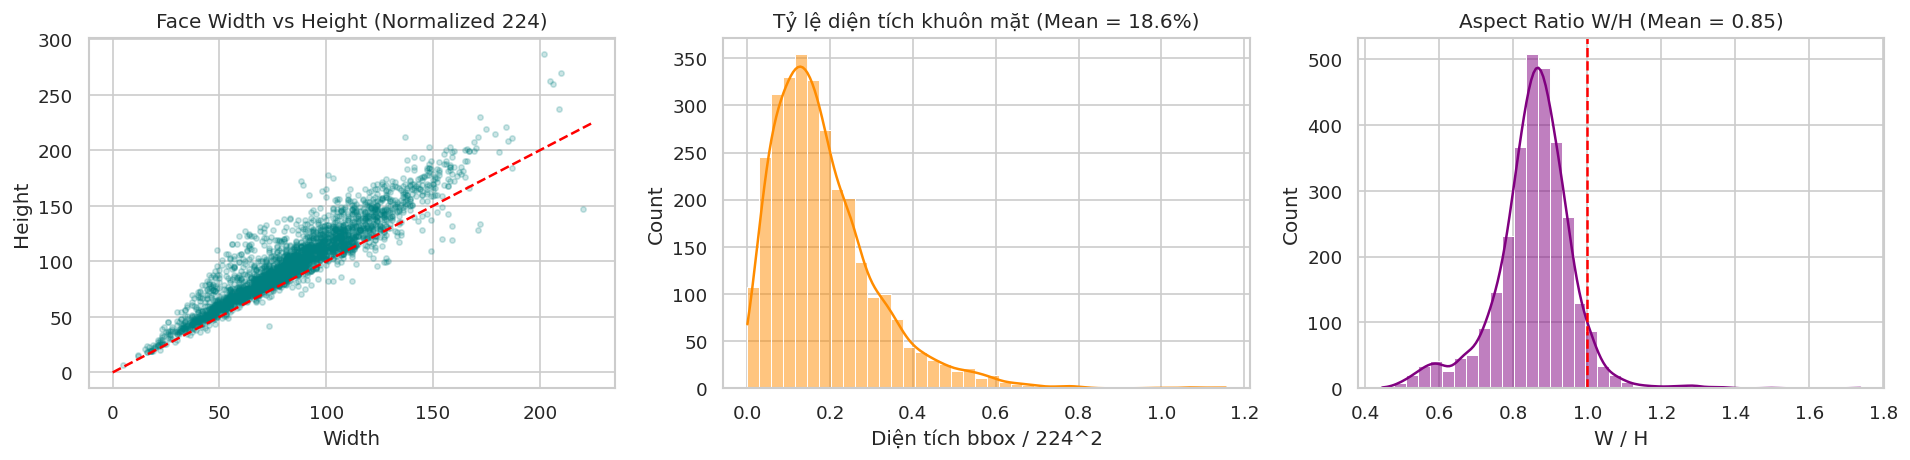

In [8]:
# Cell 8: Kiểm tra file BBox trên mẫu ngẫu nhiên
SAMPLE_CHECK_SIZE = 3000
rng = np.random.default_rng(42)
sample_keys = rng.choice(list(train_meta.keys()), size=min(SAMPLE_CHECK_SIZE, len(train_meta)), replace=False)

bb_exists = 0
bb_empty  = 0
bb_valid  = 0

face_widths  = []
face_heights = []
face_areas   = []
aspect_ratios = []

for rel_path in tqdm(sample_keys, desc="Khảo sát Bounding Boxes"):
    img_path = os.path.join(DATA_ROOT, rel_path)
    bb_path  = os.path.splitext(img_path)[0] + "_BB.txt"
    
    if os.path.exists(bb_path):
        bb_exists += 1
        try:
            with open(bb_path, "r") as f:
                content = f.readline().strip()
            parts = content.split()
            if len(parts) >= 4:
                x, y, w, h = map(float, parts[:4])
                if w > 0 and h > 0:
                    bb_valid += 1
                    face_widths.append(w)
                    face_heights.append(h)
                    face_areas.append((w * h) / (224 * 224))
                    aspect_ratios.append(w / h)
                else:
                    bb_empty += 1
            else:
                bb_empty += 1
        except Exception:
            bb_empty += 1

print(f"\n📊 Kết quả khảo sát trên {len(sample_keys):,} mẫu:")
print(f"   - File _BB.txt tồn tại  : {bb_exists:,} ({bb_exists/len(sample_keys)*100:.1f}%)")
print(f"   - File _BB.txt hợp lệ   : {bb_valid:,} ({bb_valid/len(sample_keys)*100:.1f}%)")
print(f"   - File _BB.txt rỗng/lỗi : {bb_empty:,} ({bb_empty/len(sample_keys)*100:.1f}%)")

if bb_valid > 0:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    
    # 1. Kích thước W vs H
    axes[0].scatter(face_widths, face_heights, alpha=0.2, color="teal", s=10)
    axes[0].plot([0, 224], [0, 224], color="red", linestyle="--")
    axes[0].set_title("Face Width vs Height (Normalized 224)")
    axes[0].set_xlabel("Width")
    axes[0].set_ylabel("Height")
    
    # 2. Diện tích tương đối
    sns.histplot(face_areas, bins=40, ax=axes[1], color="darkorange", kde=True)
    axes[1].set_title(f"Tỷ lệ diện tích khuôn mặt (Mean = {np.mean(face_areas)*100:.1f}%)")
    axes[1].set_xlabel("Diện tích bbox / 224^2")
    
    # 3. Aspect Ratio W/H
    sns.histplot(aspect_ratios, bins=40, ax=axes[2], color="purple", kde=True)
    axes[2].axvline(1.0, color="red", linestyle="--")
    axes[2].set_title(f"Aspect Ratio W/H (Mean = {np.mean(aspect_ratios):.2f})")
    axes[2].set_xlabel("W / H")
    
    plt.tight_layout()
    plt.show()

## 🖼️ 9. Visual Gallery — Trực quan hóa Mẫu Dữ liệu Thực tế
Hiển thị ảnh gốc và ảnh sau khi thực hiện **Expanded Square Crop 1.5×** với `cv2.BORDER_REFLECT_101`:
- Thấy rõ ngữ cảnh viền màn hình (Screen bezel), viền giấy (Paper boundary) — những tín hiệu spatial then chốt của Face PAD.

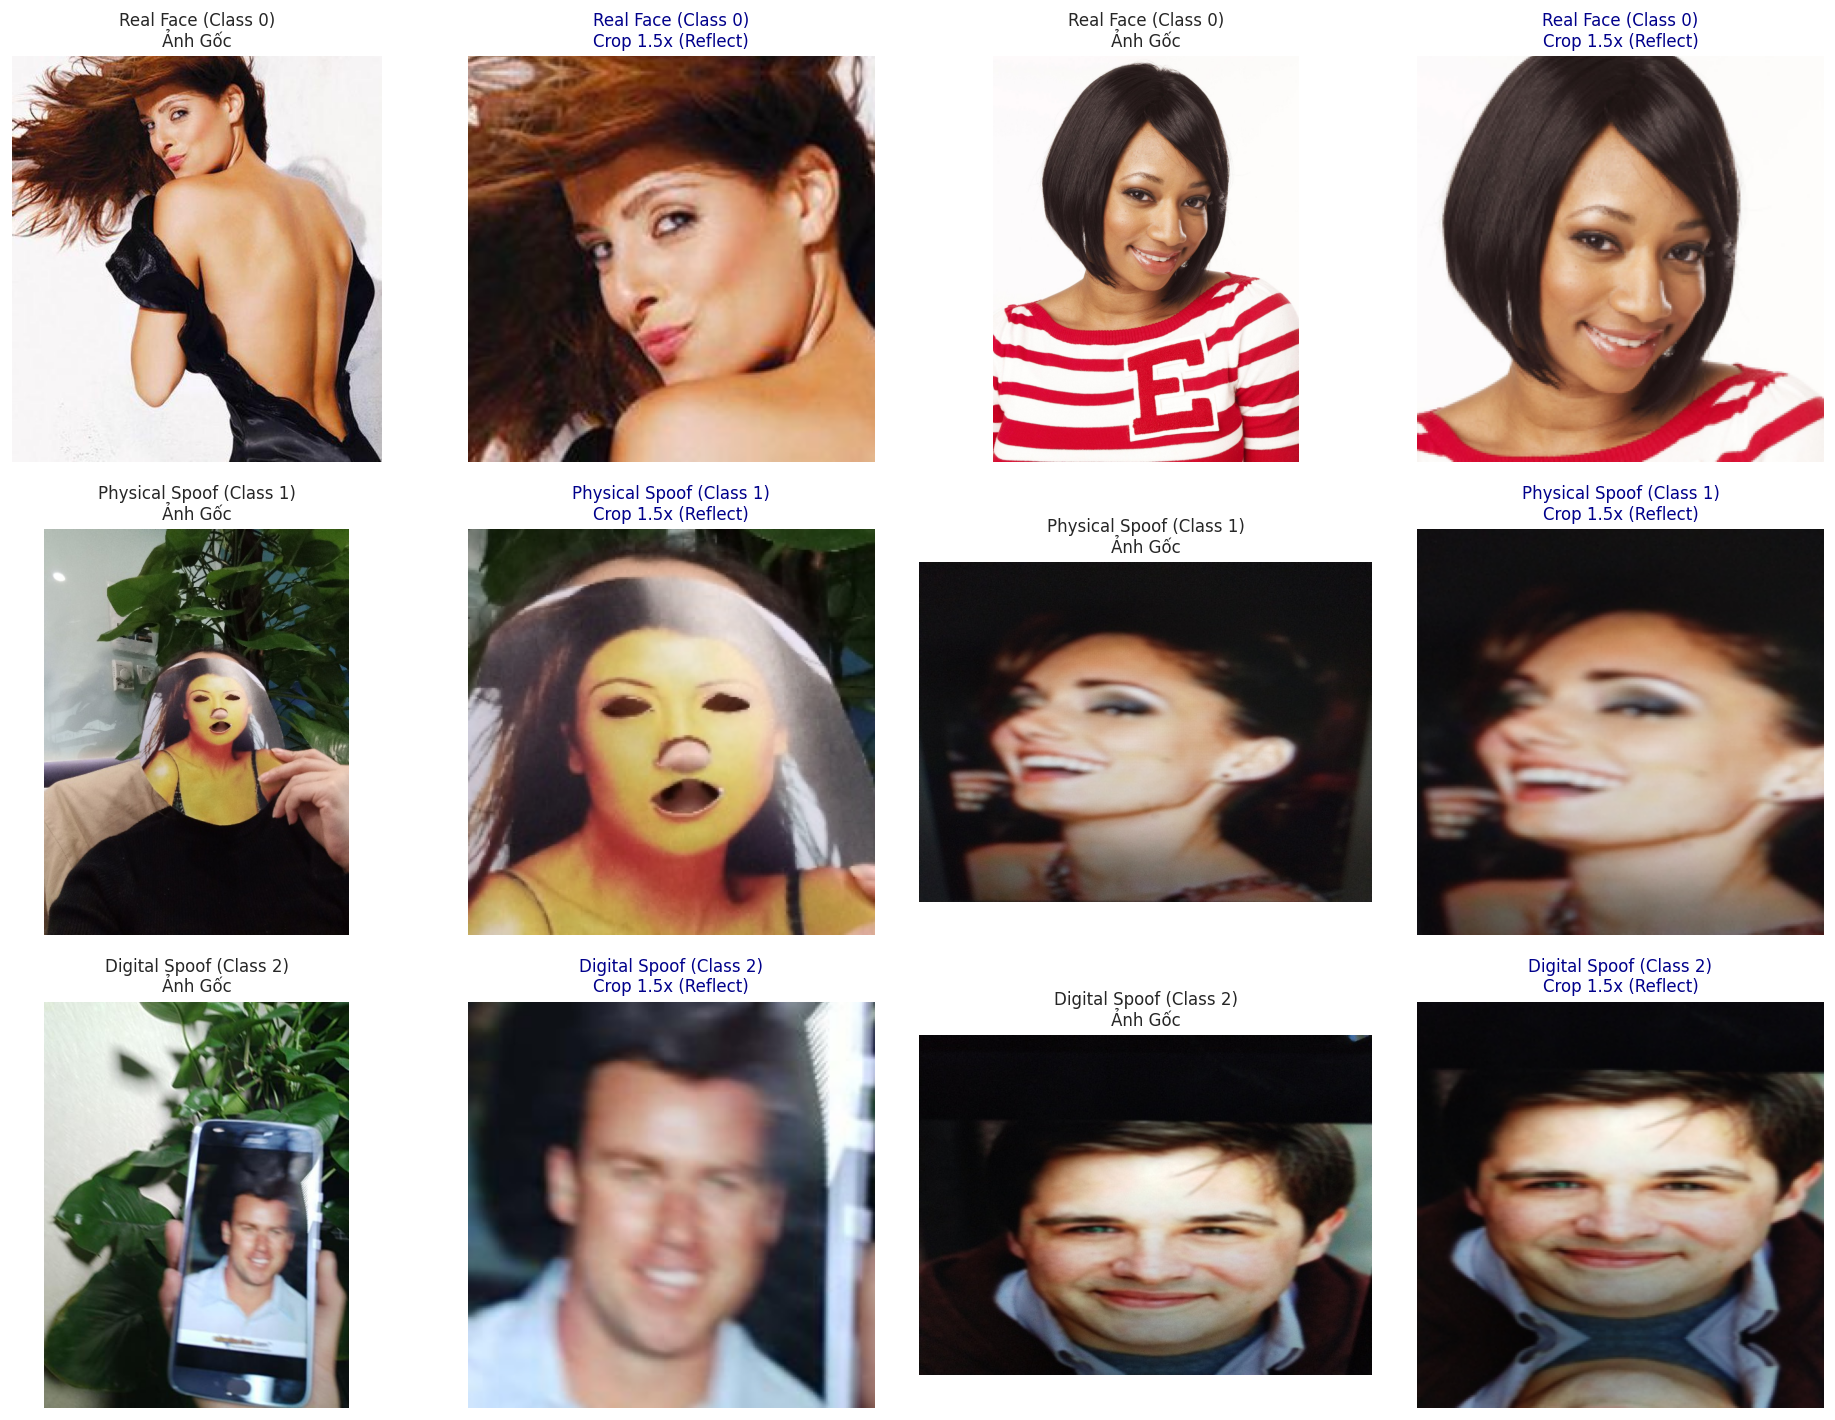

In [10]:
# ==============================================================================
# Cell 9: Visual Gallery mẫu ảnh 3 Class (ĐÃ FIX KEYERROR)
# ==============================================================================
def load_and_crop(rel_path):
    img_path = os.path.join(DATA_ROOT, rel_path)
    image = cv2.imread(img_path)
    if image is None:
        return None, None
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h_img, w_img = image_rgb.shape[:2]
    
    bb_path = os.path.splitext(img_path)[0] + "_BB.txt"
    cropped_img = None
    if os.path.exists(bb_path):
        try:
            with open(bb_path, "r") as f:
                parts = f.readline().strip().split()
            if len(parts) >= 4:
                x, y, w, h = map(float, parts[:4])
                x = x / 224 * w_img
                y = y / 224 * h_img
                w = w / 224 * w_img
                h = h / 224 * h_img
                
                max_dim = max(w, h)
                cx, cy = x + w / 2, y + h / 2
                crop_size = int(max_dim * 1.5)
                
                x_start = int(cx - crop_size / 2)
                y_start = int(cy - crop_size / 2)
                
                crop_x1, crop_y1 = max(0, x_start), max(0, y_start)
                crop_x2, crop_y2 = min(w_img, x_start + crop_size), min(h_img, y_start + crop_size)
                
                top_pad = int(max(0, -y_start))
                left_pad = int(max(0, -x_start))
                bottom_pad = int(max(0, (y_start + crop_size) - h_img))
                right_pad = int(max(0, (x_start + crop_size) - w_img))
                
                if crop_x2 > crop_x1 and crop_y2 > crop_y1:
                    c_patch = image_rgb[crop_y1:crop_y2, crop_x1:crop_x2, :]
                else:
                    c_patch = np.zeros((0, 0, 3), dtype=image_rgb.dtype)
                
                cropped_img = cv2.copyMakeBorder(c_patch, top_pad, bottom_pad, left_pad, right_pad, cv2.BORDER_REFLECT_101)
                cropped_img = cv2.resize(cropped_img, (224, 224), interpolation=cv2.INTER_AREA)
        except Exception:
            pass
            
    if cropped_img is None:
        cropped_img = cv2.resize(image_rgb, (224, 224))
        
    return image_rgb, cropped_img

# 1. Khởi tạo sẵn dict với đủ cả 3 class (0: Real, 1: Physical, 2: Digital)
sample_per_class = {0: [], 1: [], 2: []}

for k, v in train_meta.items():
    c = label_3c(v)
    if len(sample_per_class[c]) < 2:
        # Chỉ lấy ảnh thực sự tồn tại trên đĩa để hiển thị mượt mà
        if os.path.exists(os.path.join(DATA_ROOT, k)):
            sample_per_class[c].append(k)
            
    # CHỈ DỪNG KHI CẢ 3 CLASS ĐỀU ĐÃ ĐỦ 2 MẪU
    if all(len(samples) >= 2 for samples in sample_per_class.values()):
        break

# 2. Vẽ Gallery
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
cls_titles = {0: "Real Face (Class 0)", 1: "Physical Spoof (Class 1)", 2: "Digital Spoof (Class 2)"}

for row, c in enumerate([0, 1, 2]):
    keys = sample_per_class.get(c, [])
    for col_pair, k in enumerate(keys):
        raw_img, crop_img = load_and_crop(k)
        if raw_img is not None:
            col_raw = col_pair * 2
            col_crop = col_pair * 2 + 1
            
            axes[row, col_raw].imshow(raw_img)
            axes[row, col_raw].set_title(f"{cls_titles[c]}\nẢnh Gốc", fontsize=10)
            axes[row, col_raw].axis("off")
            
            axes[row, col_crop].imshow(crop_img)
            axes[row, col_crop].set_title(f"{cls_titles[c]}\nCrop 1.5x (Reflect)", fontsize=10, color="darkblue")
            axes[row, col_crop].axis("off")

plt.tight_layout()
plt.savefig("celeba_spoof_sample_gallery.png", dpi=300)
plt.show()


## 📝 10. Báo cáo Thống kê Tổng hợp (Executive Summary)
Xuất toàn bộ kết quả phân tích thống kê ra file JSON để trích dẫn vào báo cáo đồ án PBL6 hoặc paper nghiên cứu:

In [11]:
# Cell 10: Xuất kết quả tổng hợp
summary_report = {
    "dataset": "CelebA-Spoof (Intra-test Protocol)",
    "total_images": {
        "train": len(train_meta),
        "test": len(test_meta),
        "sum": len(train_meta) + len(test_meta)
    },
    "subjects": {
        "train_subjects": len(train_subjects),
        "test_subjects": len(test_subjects),
        "overlap_subjects": len(overlap_subjects),
        "is_subject_disjoint": (len(overlap_subjects) == 0)
    },
    "class_distribution_train": {class_labels[c]: int(train_3c_counts[c]) for c in [0, 1, 2]},
    "class_distribution_test":  {class_labels[c]: int(test_3c_counts[c])  for c in [0, 1, 2]},
    "attack_distribution_train": {ATTACK_TYPE_NAMES.get(k, str(k)): int(v) for k, v in train_attack_counts.items()},
    "attack_distribution_test":  {ATTACK_TYPE_NAMES.get(k, str(k)): int(v) for k, v in test_attack_counts.items()}
}

with open("celeba_spoof_eda_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary_report, f, indent=4, ensure_ascii=False)

print("✅ Đã xuất báo cáo tổng hợp: celeba_spoof_eda_summary.json")
print("✅ Đã lưu hình ảnh gallery: celeba_spoof_sample_gallery.png")
print("\nHoàn thành phân tích EDA CelebA-Spoof!")

✅ Đã xuất báo cáo tổng hợp: celeba_spoof_eda_summary.json
✅ Đã lưu hình ảnh gallery: celeba_spoof_sample_gallery.png

Hoàn thành phân tích EDA CelebA-Spoof!
